# Try to import TRACE

In [4]:
from tbsim.configs.scene_edit_config import SceneEditingConfig
from tbsim.evaluation.policy_composers import Diffuser

In [20]:
cfg = SceneEditingConfig()
cfg.ckpt.policy.ckpt_dir = "/home/linh/ductai_nguyen_ws/trace/ckpt/trace/orca_mixed"
cfg.ckpt.policy.ckpt_key = "iter40000"
composer = Diffuser(cfg, "cpu")

In [25]:
policy, _ = composer.get_policy()

Checkpoint path: /home/linh/ductai_nguyen_ws/trace/ckpt/trace/orca_mixed/iter40000.ckpt
Config path: /home/linh/ductai_nguyen_ws/trace/ckpt/trace/orca_mixed/config.json
DIFFUSER: Dropping map input conditioning with p = 0.100000 during training...
DIFFUSER: Dropping neighbor traj input conditioning with p = 0.100000 during training...
[ models/temporal ] Channel dimensions: [(38, 64), (64, 128), (128, 256)]
DIFFUSER: using EMA... val and get_action will use ema model


In [32]:
policy.model.nets

ModuleDict(
  (policy): DiffuserModel(
    (agent_hist_encoder): AgentHistoryEncoder(
      (traj_mlp): MLP(
          input_dim=248
          output_shape=[128]
          layer_dims=(248, 248, 128, 128)
          layer_func=Linear
          dropout=None
          act=ReLU
          output_act=None
      )
    )
    (neighbor_hist_encoder): NeighborHistoryEncoder(
      (agt_hist_encoder): AgentHistoryEncoder(
        (traj_mlp): MLP(
            input_dim=248
            output_shape=[128]
            layer_dims=(248, 248, 128, 128)
            layer_func=Linear
            dropout=None
            act=ReLU
            output_act=None
        )
      )
    )
    (map_encoder): MapEncoder(
      (encoder_heads): RasterizedMapEncoder(
        (map_model): Module(
          (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=Tru

# Try NavMesh

In [10]:
import numpy as np
import shapely.geometry as geom
import shapely.ops as ops
from typing import List, Tuple
from pathfinder.navmesh import Navmesh
from arena_simulation_setup.tree.World import World
from pathlib import Path

# ---------------------------------------------------------
# STEP 1 — Your existing ORCA converter
# ---------------------------------------------------------
def arena_world_to_orca_map(world: World, wall_thickness: float = 0.2) -> List[List[Tuple[float, float]]]:
    print("Converting Arena world to ORCA map format...")
    orca_map = []
    world_descr = world.load()

    for zone in world_descr.zones:
        for wall in zone.walls:
            start = np.array([wall.start.x, wall.start.y])
            end = np.array([wall.end.x, wall.end.y])

            d = end - start
            length = np.linalg.norm(d)
            if length < 1e-6:
                continue

            t = d / length
            n = np.array([-t[1], t[0]])
            half_w = wall_thickness / 2

            corners = [
                start + n * half_w,
                end + n * half_w,
                end - n * half_w,
                start - n * half_w,
            ]

            obstacle = geom.Polygon(corners)
            orca_map.append([(float(x), float(y)) for x, y in obstacle.exterior.coords[:-1]])

    return orca_map


# ---------------------------------------------------------
# STEP 2 — Build NavMesh from ORCA map
# ---------------------------------------------------------
def build_navmesh_from_orca(
    orca_map: List[List[Tuple[float, float]]],
    world_boundary: List[Tuple[float, float]],
    robot_radius: float = 0.1,
):
    """
    Improved Navmesh builder using centroid filtering to preserve connectivity.
    """
    # 1. Build outer boundary and obstacles
    outer = geom.Polygon(world_boundary)
    
    # 2. Inflate obstacles by robot radius
    # Using a small 'resolution' for buffer to keep vertex count manageable
    inflated_obstacles = [geom.Polygon(p).buffer(robot_radius, quad_segs=2) for p in orca_map]
    
    # 3. Define Free Space
    if inflated_obstacles:
        merged_obstacles = ops.unary_union(inflated_obstacles)
        free_space = outer.difference(merged_obstacles)
    else:
        free_space = outer

    if free_space.is_empty:
        raise RuntimeError("No free space! Robot radius might be too large for the layout.")

    # 4. Extract all points to ensure triangulation covers all corners
    # This includes boundary points and all obstacle corners
    all_points = []
    if free_space.geom_type == 'Polygon':
        polys = [free_space]
    else:
        polys = list(free_space.geoms)

    for poly in polys:
        all_points.extend(poly.exterior.coords)
        for hole in poly.interiors:
            all_points.extend(hole.coords)

    # 5. Triangulate the point set
    # Using MultiPoint ensures Delaunay covers the entire bounding box
    raw_triangles = ops.triangulate(geom.MultiPoint(all_points))

    # 6. Filter triangles by Centroid
    # We only keep triangles if their center is inside the free space
    valid_triangles = []
    for tri in raw_triangles:
        # Optimization: Only check triangles that have a reasonable area
        if tri.area < 1e-9:
            continue
            
        # The key fix: if the center is in free space, the triangle is walkable
        if free_space.contains(tri.centroid):
            valid_triangles.append(tri)

    # 7. Convert to Path-Finder format (Vertices and Indices)
    vertices = []
    vertex_map = {}

    def get_vertex_id(pt):
        # Rounding to 4 decimals prevents microscopic gaps (weld vertices)
        key = (round(pt[0], 4), round(pt[1], 4))
        if key not in vertex_map:
            vertex_map[key] = len(vertices)
            vertices.append((pt[0], 0.0, pt[1]))
        return vertex_map[key]

    polygons = []
    for tri in valid_triangles:
        coords = list(tri.exterior.coords)[:-1]
        indices = [get_vertex_id(c) for c in coords]
        polygons.append(indices)

    navmesh = Navmesh(vertices, polygons)
    print(f"✓ Navmesh built with {len(polygons)} connected triangles")
    return navmesh

# ---------------------------------------------------------
# STEP 3 — Example Usage
# ---------------------------------------------------------
def build_navmesh_from_world(world:World):

    # Convert world → ORCA obstacle polygons
    orca_map = arena_world_to_orca_map(world)

    # Define world boundary (must enclose everything)
    xmin,ymin,xmax,ymax = np.inf, np.inf, -np.inf, -np.inf
    for zone in world.load().zones:
        xmin = min(xmin, zone.floor.pos.x - zone.floor.x_length/2)
        xmax = max(xmax, zone.floor.pos.x + zone.floor.x_length/2)
        ymin = min(ymin, zone.floor.pos.y - zone.floor.y_length/2)
        ymax = max(ymax, zone.floor.pos.y + zone.floor.y_length/2)

    eps = 1e-3
    world_boundary = [
        (xmin - eps, ymin - eps),
        (xmax + eps, ymin - eps),
        (xmax + eps, ymax + eps),
        (xmin - eps, ymax + eps),
    ]
    print(world_boundary)

    navmesh = build_navmesh_from_orca(
        orca_map,
        world_boundary,
        robot_radius=0.3,
    )

    return navmesh


# ---------------------------------------------------------
# STEP 4 — Planning Example
# ---------------------------------------------------------
def plan_example(navmesh, start, goal):
    start = (start[0], 0.0, start[1])
    goal  = (goal[0], 0.0, goal[1])
    print("Start inside:", navmesh.sample(start))
    print("Goal inside:", navmesh.sample(goal))


    path = navmesh.search_path(start, goal)

    print("Path:")
    for p in path:
        print(p)

    return path
def funnel_filter(start: Tuple[float, float, float], 
                  goal: Tuple[float, float, float], 
                  portals: List[Tuple[np.ndarray, np.ndarray]]) -> List[Tuple[float, float, float]]:
    """
    start, goal: (x, 0, z) tuples
    portals: List of (left_point, right_point) where points are np.array([x, 0, z])
    """
    pts = [start]
    
    # Initialize funnel
    portal_apex = np.array(start)
    portal_left = np.array(start)
    portal_right = np.array(start)
    
    left_index = 0
    right_index = 0
    
    # Add goal as the final portal
    goal_pt = np.array(goal)
    all_portals = portals + [(goal_pt, goal_pt)]

    for i, (left, right) in enumerate(all_portals):
        # Update Right side
        if tri_area_2d(portal_apex, portal_right, right) <= 0:
            if np.array_equal(portal_apex, portal_right) or tri_area_2d(portal_apex, portal_left, right) > 0:
                portal_right = right
                right_index = i
            else:
                pts.append(tuple(portal_left))
                portal_apex = portal_left
                portal_right = portal_apex
                right_index = left_index
                # Restart from new apex
                continue

        # Update Left side
        if tri_area_2d(portal_apex, portal_left, left) >= 0:
            if np.array_equal(portal_apex, portal_left) or tri_area_2d(portal_apex, portal_right, left) < 0:
                portal_left = left
                left_index = i
            else:
                pts.append(tuple(portal_right))
                portal_apex = portal_right
                portal_left = portal_apex
                left_index = right_index
                # Restart from new apex
                continue

    pts.append(goal)
    return pts

def tri_area_2d(a, b, c):
    """Returns the signed area of a triangle in the XZ plane."""
    return (b[0] - a[0]) * (c[2] - a[2]) - (c[0] - a[0]) * (b[2] - a[2])

import matplotlib.pyplot as plt
from typing import List, Tuple
    
def visualize_with_mesh(orca_map, path, navmesh: Navmesh, start_pos, goal_pos):
    plt.figure(figsize=(10, 12))
    
    # 1. Draw NavMesh Triangles (Light Blue)
    for poly_indices in navmesh._polygons:
        # Get coordinates (remember Navmesh is x, y, z where z is our 2D y)
        pts = [navmesh._vertices[i] for i in poly_indices]
        xs = [p[0] for p in pts] + [pts[0][0]]
        ys = [p[2] for p in pts] + [pts[0][2]]
        plt.fill(xs, ys, facecolor='skyblue', edgecolor='white', alpha=0.5, linewidth=0.5)

    # 2. Draw Obstacles (Red)
    for poly in orca_map:
        xs = [p[0] for p in poly] + [poly[0][0]]
        ys = [p[1] for p in poly] + [poly[0][1]]
        plt.plot(xs, ys, color='red', linewidth=2)

    # 3. Draw Path (Green)
    if path:
        path_x = [p[0] for p in path]
        path_y = [p[2] for p in path]
        plt.plot(path_x, path_y, 'g-', linewidth=3, label="Planned Path")
        plt.scatter(path_x, path_y, color='#00FF00')

    # 4. Mark Start and Goal
    plt.scatter([start_pos[0]], [start_pos[1]], color='blue', s=100, label="Start", zorder=5)
    plt.scatter([goal_pos[0]], [goal_pos[1]], color='purple', s=100, label="Goal", zorder=5)

    plt.gca().set_aspect("equal")
    plt.legend()
    plt.title("NavMesh")
    plt.grid(True)
    plt.show()

Converting Arena world to ORCA map format...
Converting Arena world to ORCA map format...
[(-0.001, -0.001), (25.001, -0.001), (25.001, 34.201), (-0.001, 34.201)]
✓ Navmesh built with 357 connected triangles
Start inside: (1.9999999999999996, 0.0, 3.0)
Goal inside: (15.0, 0.0, 27.0)
Path:
(2.0, 0.0, 3.0)
(0.4, 0.0, 0.4)
(7.6000000000000005, 0.0, 3.25)
(7.6000000000000005, 0.0, 1.75)
(7.6878679656440365, 0.0, 1.9621320343559643)
(7.687867965644036, 0.0, 3.0378679656440357)
(7.9, 0.0, 2.05)
(7.9, 0.0, 2.95)
(8.1, 0.0, 2.05)
(8.1, 0.0, 2.95)
(8.312132034355963, 0.0, 1.9621320343559643)
(8.312132034355963, 0.0, 3.0378679656440357)
(8.4, 0.0, 1.75)
(10.75, 0.0, 0.4)
(11.6, 0.0, 0.4)
(8.4, 0.0, 3.25)
(12.4, 0.0, 0.4)
(8.4, 0.0, 5.0)
(12.4, 0.0, 9.6)
(8.4, 0.0, 6.8)
(11.6, 0.0, 10.0)
(8.4, 0.0, 10.05)
(11.6, 0.0, 10.0)
(11.687867965644037, 0.0, 10.212132034355964)
(11.787867965644036, 0.0, 10.362132034355964)
(11.787867965644036, 0.0, 12.737867965644037)
(8.4, 0.0, 10.1)
(11.687867965644037, 

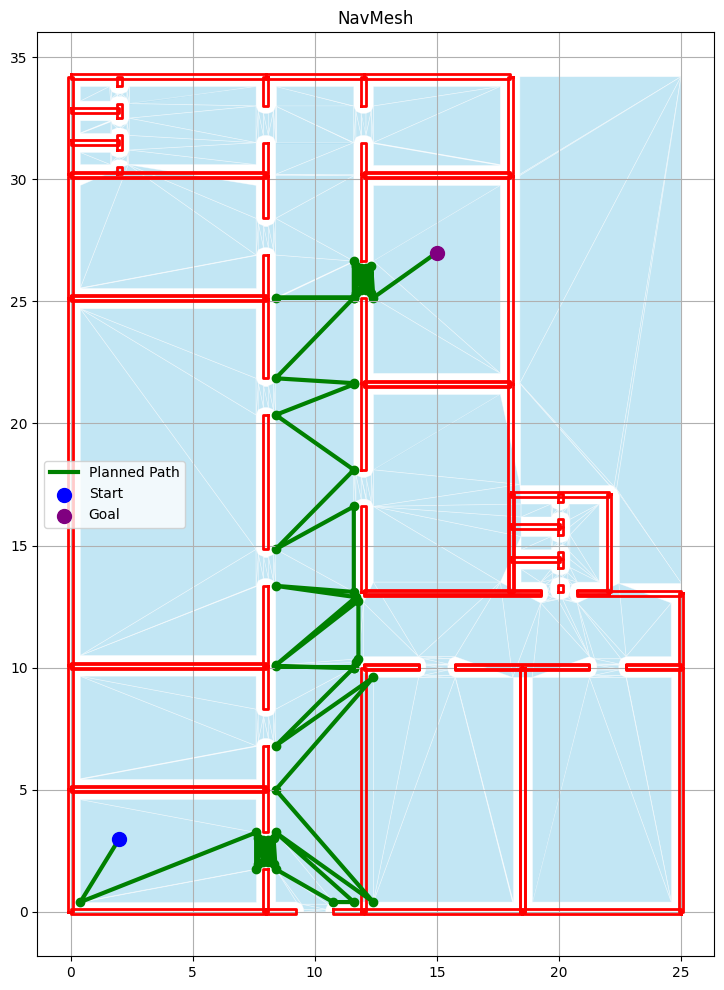

In [4]:
world_path = "/home/linh/ductai_nguyen_ws/Arena_ws/install/arena_simulation_setup/share/arena_simulation_setup/worlds/hospital_1"
world = World(path=Path(world_path))
orca_map = arena_world_to_orca_map(world)
navmesh = build_navmesh_from_world(world)
path = plan_example(navmesh, (2.0, 3.0), (15.0, 27.0))
print("Length of path:", len(path))
# visualize_map_and_path(orca_map, path)
visualize_with_mesh(orca_map, path, navmesh, (2.0, 3.0), (15.0, 27.0))

# Try Theta*

[(6.0, 0.0, 2.5), (8.1, 0.0, 2.9000000000000004), (9.0, 0.0, 4.1000000000000005), (11.700000000000001, 0.0, 10.200000000000001), (11.9, 0.0, 10.4), (14.4, 0.0, 10.4), (21.400000000000002, 0.0, 10.4), (21.6, 0.0, 10.200000000000001), (22.0, 0.0, 7.5)]


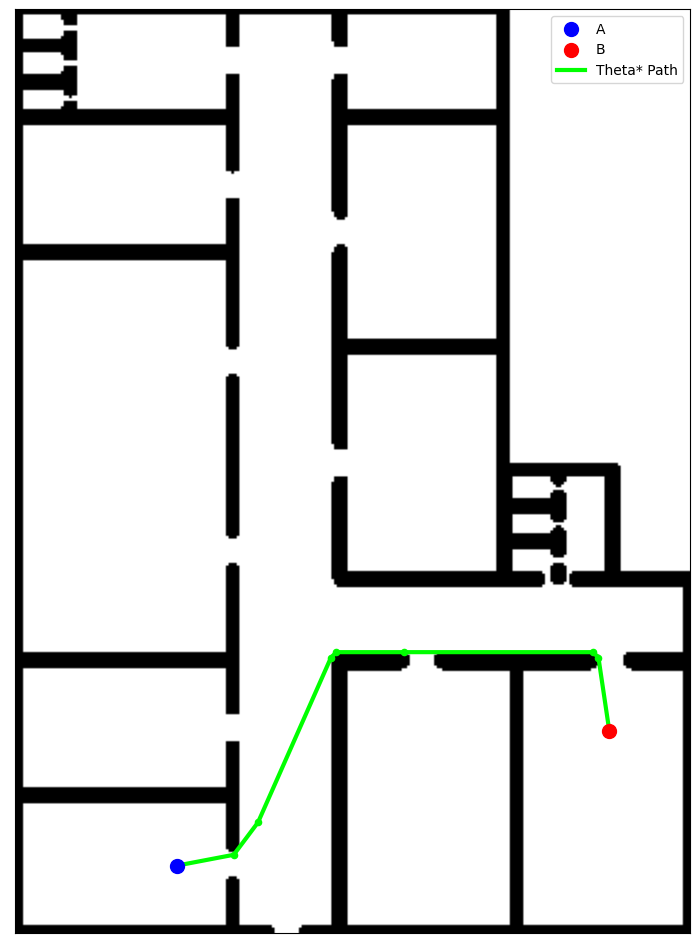

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import shapely.geometry as geom
from pathfinding3d.core.diagonal_movement import DiagonalMovement
from pathfinding3d.core.grid import Grid
from pathfinding3d.finder.theta_star import ThetaStarFinder
from pathfinding3d.finder.a_star import AStarFinder
from pathfinding3d.finder.msp import MinimumSpanningTree
from arena_simulation_setup.tree.World import World

world_path = "/home/linh/ductai_nguyen_ws/Arena_ws/install/arena_simulation_setup/share/arena_simulation_setup/worlds/hospital_1"
world = World(path=Path(world_path))

def build_grid_from_world(world, resolution=0.01):
    """
    Converts World description into a 3D numpy grid for Pathfinding3D.
    resolution: size of one grid cell in meters (0.1 = 10cm)
    """
    # 1. Determine World Bounds
    world_descr = world.load()
    xmin, ymin, xmax, ymax = np.inf, np.inf, -np.inf, -np.inf
    for zone in world_descr.zones:
        xmin = min(xmin, zone.floor.pos.x - zone.floor.x_length/2)
        xmax = max(xmax, zone.floor.pos.x + zone.floor.x_length/2)
        ymin = min(ymin, zone.floor.pos.y - zone.floor.y_length/2)
        ymax = max(ymax, zone.floor.pos.y + zone.floor.y_length/2)

    # 2. Initialize 3D Matrix (Width, Height=1, Depth)
    # We use (x, z, y) logic to match Pathfinding3D's (x, y, z)
    width = int(np.ceil((xmax - xmin) / resolution))
    depth = int(np.ceil((ymax - ymin) / resolution))
    matrix = np.ones((width, 1, depth), dtype=np.int8) # 1 = walkable

    def world_to_grid(x, y):
        gx = int((x - xmin) / resolution)
        gy = int((y - ymin) / resolution)
        return gx, gy

    # 3. Burn Obstacles into Matrix
    # We'll use your existing wall conversion logic but fill the grid
    for zone in world_descr.zones:
        for wall in zone.walls:
            # Create a Shapely polygon for the wall (inflated by wall thickness)
            # You can also inflate by robot_radius here for safety!
            start = np.array([wall.start.x, wall.start.y])
            end = np.array([wall.end.x, wall.end.y])
            line = geom.LineString([start, end])
            # Inflate wall + robot safety margin
            obstacle_poly = line.buffer(0.3) 
            
            # Find cells covered by this obstacle
            o_xmin, o_ymin, o_xmax, o_ymax = obstacle_poly.bounds
            gx1, gy1 = world_to_grid(o_xmin, o_ymin)
            gx2, gy2 = world_to_grid(o_xmax, o_ymax)
            
            # Clip to matrix bounds
            for ix in range(max(0, gx1), min(width, gx2 + 1)):
                for iz in range(max(0, gy1), min(depth, gy2 + 1)):
                    # Check if cell center is inside the polygon
                    cell_pt = geom.Point(xmin + ix*resolution, ymin + iz*resolution)
                    if obstacle_poly.contains(cell_pt):
                        matrix[ix, 0, iz] = 0 # 0 = obstacle

    return matrix, (xmin, ymin), resolution

def visualize_theta_star(matrix, path, start_node, end_node, origin, resolution):
    """
    Visualizes the occupancy grid and the resulting Theta* path.
    """
    # 1. Matplotlib 2D Top-down view
    plt.figure(figsize=(10, 12))
    
    # Plot the grid (transpose to align axes: [width, depth])
    # We show the 0th slice of our 3D matrix
    plt.imshow(matrix[:, 0, :].T, origin='lower', cmap='gray',
               extent=[origin[0], origin[0] + matrix.shape[0]*resolution,
                       origin[1], origin[1] + matrix.shape[2]*resolution])
    plt.scatter([start_node.x*resolution + origin[0]], [start_node.z*resolution + origin[1]], 
                color='blue', s=100, label="A", zorder=5)
    plt.scatter([end_node.x*resolution + origin[0]], [end_node.z*resolution + origin[1]], 
                color='red', s=100, label="B", zorder=5)
    
    # Plot Path
    if path:
        path_x = [p[0] for p in path]
        path_y = [p[2] for p in path]
        plt.plot(path_x, path_y, color='#00FF00', linewidth=3, label="Theta* Path")
        plt.scatter(path_x, path_y, color='#00FF00', s=20)

    # plt.title("Theta* Grid and Any-Angle Path")
    # plt.xlabel("X (meters)")
    # plt.ylabel("Y (meters)")
    plt.legend()
    # plt.grid(True, alpha=0.3)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# --- Execution Flow ---

# 1. Build the grid (using the logic from the previous step)
matrix, origin, res = build_grid_from_world(world, resolution=0.1)

# 2. Setup the Grid object for Pathfinding3D
grid = Grid(matrix=matrix)
start_pos = (6.0, 2.5)
goal_pos = (22.0, 7.5)

# Convert world coordinates to grid nodes
def to_grid_coords(pos, origin, res):
    return int((pos[0] - origin[0]) / res), 0, int((pos[1] - origin[1]) / res)

start_node = grid.node(*to_grid_coords(start_pos, origin, res))
end_node = grid.node(*to_grid_coords(goal_pos, origin, res))

# 3. Find Path
finder = ThetaStarFinder(diagonal_movement=DiagonalMovement.always)
# finder = AStarFinder(diagonal_movement=DiagonalMovement.never)
path_nodes, runs = finder.find_path(start_node, end_node, grid)

# 4. Convert nodes back to world points
world_path = [(origin[0] + n.x*res, 0.0, origin[1] + n.z*res) for n in path_nodes]
print(world_path)

# 5. Visual Debugging
visualize_theta_star(matrix, world_path, start_node, end_node, origin, res)

# 6. Optional: Generate the Interactive 3D HTML file
# This requires: pip install pathfinding3d[vis]
# grid.visualize(
#     path=path_nodes,
#     start=start_node,
#     end=end_node,
#     save_html=True,
#     save_to="theta_star_debug.html",
#     always_show=True
# )

In [1]:
import numpy as np
import csv
def convert_csv_to_trajectories(csv_data):
    text_crowd_agent_trajectories_dict = {}
    n_column = len(csv_data[0])
    for i in range(n_column):
        time_step = csv_data[0][i]
        agent_id = csv_data[1][i]
        x = float(csv_data[2][i])
        y = float(csv_data[3][i])
        text_crowd_agent_trajectories_dict[agent_id] = text_crowd_agent_trajectories_dict.get(agent_id, []) + [[x, y]]
    text_crowd_agent_trajectories = [traj for traj in text_crowd_agent_trajectories_dict.values()]
    return np.array(text_crowd_agent_trajectories).transpose(1,0,2)

In [28]:
def trace_output_to_socnavbench_scenario(trace_agents_trajectories, output_csv_path, target_fps=25, original_fps=0.2):
    """
    Convert trace output to SocNavBench format with interpolation to target FPS.
    
    Args:
        trace_agents_trajectories: trajectory data with 'pred_pos' key
        output_csv_path: path to save the CSV file
        target_fps: target frame rate (default 25 fps)
        original_fps: original frame rate (default 0.2 fps, i.e., 5 seconds per frame)
    """
    print("Collecting and interpolating trajectory points from TRACE output...")
    T, N, _ = trace_agents_trajectories['pred_pos'].shape
    
    # Calculate interpolation factor
    interp_factor = target_fps / original_fps  # 25 / 0.2 = 125 frames per original frame
    
    all_samples = []
    frame_offset = 200 # For ease of loading
    # frame_counter = 1
    
    for agent_id in range(N):
        frame_counter = 1
        for frame_idx in range(T - 1):
            # Get current and next position
            pos_current = trace_agents_trajectories['pred_pos'][frame_idx, agent_id]
            pos_next = trace_agents_trajectories['pred_pos'][frame_idx + 1, agent_id]
            
            # Interpolate between current and next position
            for interp_step in range(int(interp_factor)):
                alpha = interp_step / interp_factor
                x = pos_current[0] + alpha * (pos_next[0] - pos_current[0])
                y = pos_current[1] + alpha * (pos_next[1] - pos_current[1])
                
                all_samples.append({
                    'frame': frame_counter+frame_offset,
                    'id': agent_id,
                    'x': x,
                    'y': y
                })
                frame_counter += 1
        
        # Add the final position for this agent
        x, y = trace_agents_trajectories['pred_pos'][T - 1, agent_id]
        all_samples.append({
            'frame': frame_counter + frame_offset,
            'id': agent_id,
            'x': x,
            'y': y
        })
    all_samples.sort(key=lambda s: (s['frame'], s['id']))
    # Prepare the four attribute rows
    row_frames = [s['frame'] for s in all_samples]
    row_ids = [s['id'] for s in all_samples]
    row_xs = [round(s['x'], 4) for s in all_samples]
    row_ys = [round(s['y'], 4) for s in all_samples]
    
    # Write to CSV
    with open(output_csv_path, "w", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(row_frames)
        writer.writerow(row_ids)
        writer.writerow(row_xs)
        writer.writerow(row_ys)
    
    print(f"Successfully converted trajectories to {output_csv_path}")
    scenario_duration = max(row_frames) / target_fps
    print(f"Total frames: {max(row_frames)}, Total agents: {len(set(row_ids))}, Scenario duration: {scenario_duration:.2f}s")

In [31]:
trace_output_to_socnavbench_scenario(trace_agents_trajectories, "/home/linh/ductai_nguyen_ws/trace_emergency.csv", target_fps=25, original_fps=1)

Successfully converted trajectories to /home/linh/ductai_nguyen_ws/trace_emergency.csv
Total frames: 5176, Total agents: 20, Scenario duration: 207.04s


Converting Arena world to ORCA map format...
(424, 12, 2)


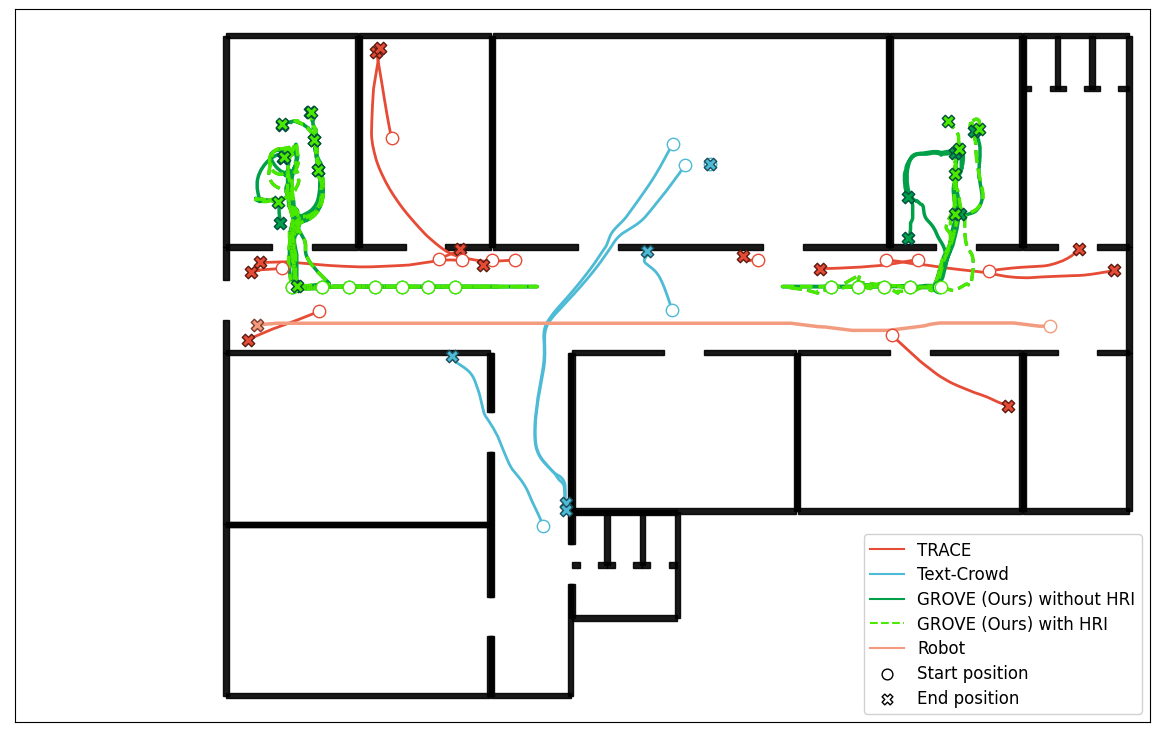

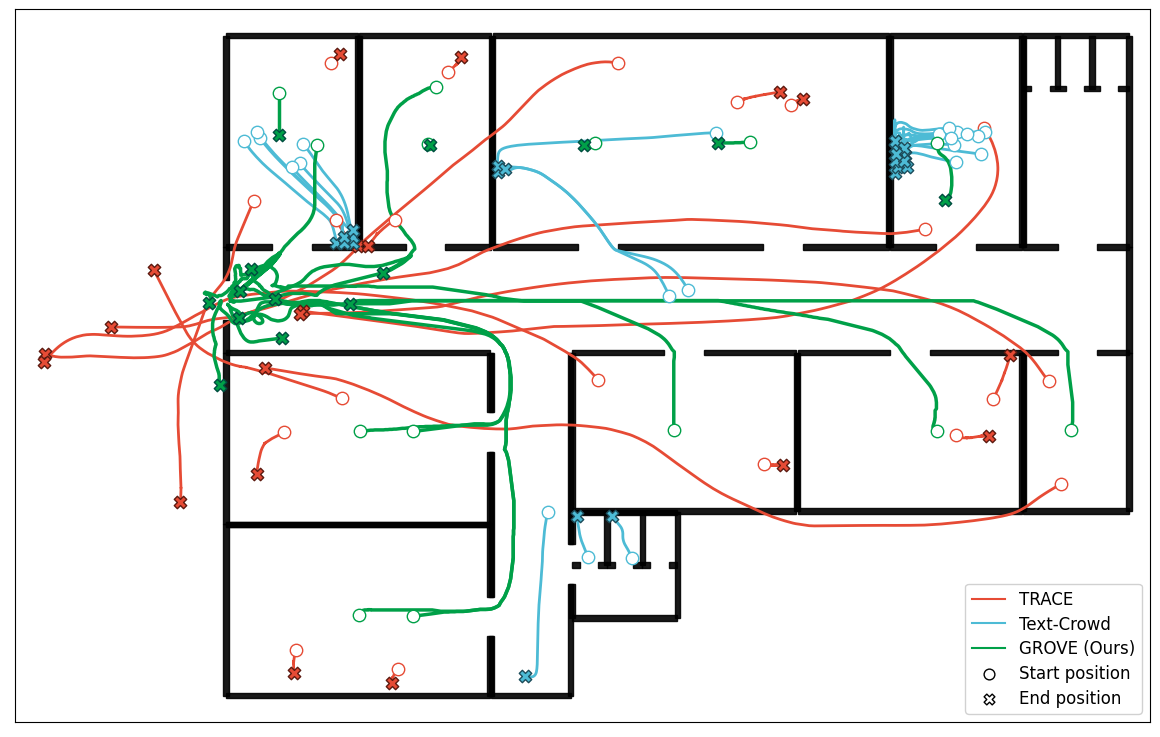

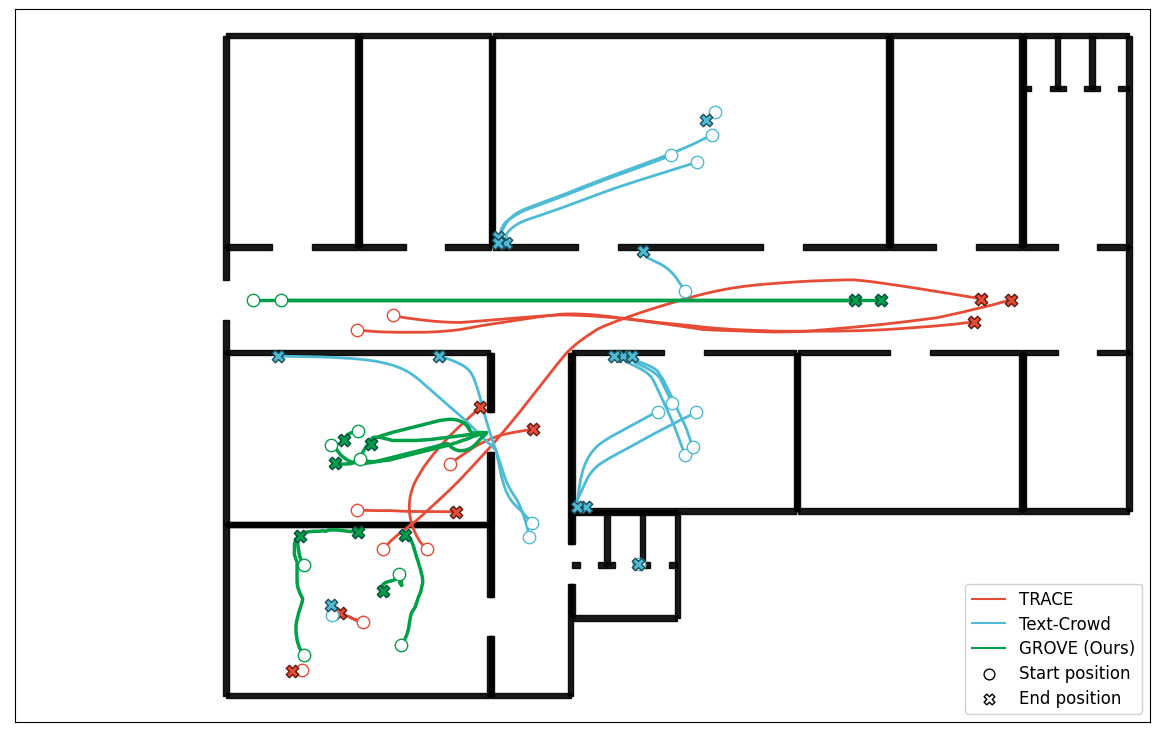

In [1]:
import os
import shapely.geometry as geom
from pathlib import Path
from arena_simulation_setup.tree.World import World
import matplotlib.pyplot as plt
import csv
from matplotlib.patches import Polygon

def arena_world_to_orca_map(world: World, wall_thickness: float = 0.2):
    print("Converting Arena world to ORCA map format...")
    orca_map = []
    world_descr = world.load()

    for zone in world_descr.zones:
        for wall in zone.walls:
            start = np.array([wall.start.x, wall.start.y])
            end = np.array([wall.end.x, wall.end.y])

            d = end - start
            length = np.linalg.norm(d)
            if length < 1e-6:
                continue

            t = d / length
            n = np.array([-t[1], t[0]])
            half_w = wall_thickness / 2

            corners = [
                start + n * half_w,
                end + n * half_w,
                end - n * half_w,
                start - n * half_w,
            ]

            obstacle = geom.Polygon(corners)
            orca_map.append([(float(x), float(y)) for x, y in obstacle.exterior.coords[:-1]])

    return orca_map
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

def visualize_trajectories(
    trace_agents_trajectories,
    text_crowd_trajectories,
    grove_trajectories,
    robot_trajectories,
    grove_trajectories_with_robot,
    orca_map,
    scenario_name,
    rotate=True,
):
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.set_position([0.1, 0.1, 0.8, 0.8])  # fixed axis box
    # -------------------------
    # Filled Obstacles
    # -------------------------
    for poly in orca_map:
        coords = [(p[0], p[1]) for p in poly]
        if rotate:
            coords = [(y, x) for (x, y) in coords]

        polygon = Polygon(
            coords,
            closed=True,
            facecolor="black",
            edgecolor="black",
            linewidth=1,
            alpha=0.9
        )
        ax.add_patch(polygon)

    # Colors (colorblind friendly)
    # trace_color = "#D55E00", "#7B3500"
    # text_crowd_color = "#0072B2", "#004065"
    # grove_color = "#009E73", "#00503A"
    # grove_color_with_robot = "#4AEA00", "#00503A"
    # robot_color = "#B59B0A", "#4F4300"
    trace_color = ("#E64B35", "#5C1A10")       # red
    text_crowd_color = ("#4DBBD5", "#1C4C5A")  # blue
    grove_color = ("#00A048", "#004D40")       # green
    grove_color_with_robot = "#4AEA00", "#00503A"
    robot_color = ("#F39B7F", "#7F3B2E")       # orange

    def plot_method(trajectories, color, linestyle, linewidth, border=False):
        for i in range(trajectories.shape[1]):
            traj = trajectories[:, i, :]
            if rotate:
                traj = traj[:, [1, 0]]

            # Plot trajectory
            # if border:
                # ax.plot(traj[:, 0], traj[:, 1],
                #     linestyle=linestyle,
                #     color="black",
                #     linewidth=linewidth*1.2)

            lines = ax.plot(traj[:, 0], traj[:, 1],
                    linestyle=linestyle,
                    color=color[0],
                    linewidth=linewidth)
            if border:
                for line in lines:
                    line.set_path_effects([
                        pe.Stroke(linewidth=2, foreground=color[1]),  # border
                        pe.Normal()
                    ])


            # --- Direction arrow (last segment only) ---
            # dx = traj[-1, 0] - traj[-2, 0]
            # dy = traj[-1, 1] - traj[-2, 1]

            # arrow = FancyArrowPatch(
            #     (traj[0, 0], traj[0, 1]),
            #     (traj[1, 0], traj[1, 1]),
            #     arrowstyle='-|>',          # clean triangular head
            #     mutation_scale=16,         # controls head size
            #     linewidth=2,
            #     color=color,
            #     zorder=10
            # )

            # ax.add_patch(arrow)

            # Optional subtle start dot
            # ax.scatter(traj[-1, 0], traj[-1, 1],
            #            color=color[0],
            #            edgecolors=color[1],
            #            marker="X",
            #            s=60,
            #            zorder=5)
            ax.scatter(traj[0,0], traj[0,1],
           marker="o",
           color="white",
           edgecolors=color[0],
           s=80,
           zorder=6)

            ax.scatter(traj[-1,0], traj[-1,1],
           marker="X",
           color=color[0],
           edgecolors=color[1],
           s=80,
           zorder=6)

    # TRACE
    plot_method(trace_agents_trajectories, trace_color, '-', 2)

    # Text-Crowd
    plot_method(text_crowd_trajectories, text_crowd_color, '-', 2)

    # GROVE (ours)
    plot_method(grove_trajectories, grove_color, '-', 2.5)
    if len(grove_trajectories_with_robot) > 0:
        plot_method(grove_trajectories_with_robot, grove_color_with_robot, '--', 2.5, True)

        # Robot
        plot_method(robot_trajectories, robot_color, '-', 2.5)

    # Legend
    ax.plot([], [], color=trace_color[0], linestyle='-', label='TRACE')
    ax.plot([], [], color=text_crowd_color[0], linestyle='-', label='Text-Crowd')

    if len(grove_trajectories_with_robot) > 0:
        ax.plot([], [], color=grove_color[0], linestyle='-', label='GROVE (Ours) without HRI')
        ax.plot([], [], color=grove_color_with_robot[0], linestyle='--', label='GROVE (Ours) with HRI')
        ax.plot([], [], color=robot_color[0], linestyle='-', label='Robot')
    else:
        ax.plot([], [], color=grove_color[0], linestyle='-', label='GROVE (Ours)')
    ax.scatter([], [], color="white", edgecolors="black", marker="o", s=60, label="Start position")
    ax.scatter([], [], color="white", edgecolors="black", marker="X", s=60, label="End position")

    # ax.set_xlabel("Y")
    # ax.set_ylabel("X")
    # ax.set_xticks([-5, 0, 35])
    # ax.set_yticks([0, 25])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-8, 35)
    ax.set_ylim(-1, 26)
    ax.legend(loc="lower right", fontsize=12, frameon=True,
    framealpha=0.9,
    borderpad=0.4,
    handlelength=2,
    labelspacing=0.4)
    # ax.legend()
    ax.grid(False)
    ax.set_aspect('equal')
    # ax.invert_xaxis()
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(f"/home/linh/ductai_nguyen_ws/{scenario_name}.png", bbox_inches="tight", dpi=400)
    plt.show()

def visualize_trajectories_all_scenarios(trace_agents_trajectories_all_scenarios, text_crowd_agent_trajectories_all_scenarios, orca_map):
    scenarios_names = trace_agents_trajectories_all_scenarios.keys()
    n_scenarios = len(scenarios_names)
    fig, axs = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 12))

    for i, scenario in enumerate(scenarios_names):
        trace_agents_trajectories = trace_agents_trajectories_all_scenarios[scenario]
        text_crowd_agent_trajectories = text_crowd_agent_trajectories_all_scenarios[scenario]

        # Plot Obstacles
        for poly in orca_map:
            xs = [p[0] for p in poly] + [poly[0][0]]
            ys = [p[1] for p in poly] + [poly[0][1]]
            axs[i].plot(xs, ys, color='red', linewidth=1)

        # Plot Trajectories
        for t in range(trace_agents_trajectories.shape[1]):
            traj = trace_agents_trajectories[:, t, :]
            axs[i].plot(traj[:, 0], traj[:, 1], color='green')
            axs[i].scatter(traj[0, 0], traj[0, 1], color='green', s=100, marker='o') # Start
            axs[i].scatter(traj[-1, 0], traj[-1, 1], color='red', s=100, marker='X') # End

        # Plot text_crowd_trajectories
        for t in range(text_crowd_agent_trajectories.shape[1]):
            traj = text_crowd_agent_trajectories[:, t, :]
            axs[i].plot(traj[:, 0], traj[:, 1], linestyle='--', color='blue')
            axs[i].scatter(traj[0, 0], traj[0, 1], color='blue', s=100, marker='o') # Start
            axs[i].scatter(traj[-1, 0], traj[-1, 1], color='orange', s=100, marker='X') # End

        axs[i].set_title("Emergency Evacuation Trajectories")
        axs[i].set_xlabel("X Position")
        axs[i].set_ylabel("Y Position")
        axs[i].legend()
        axs[i].grid(True)

        # add one legend entry per algorithm
    axs[i].plot([], [], color='green', label='Trace Trajectories')
    axs[i].plot([], [], linestyle='--', color='blue', label='Text-Crowd Trajectories')

    # add entries for the start/goal markers
    axs[i].scatter([], [], color='green', s=100, marker='o', label='Start')
    axs[i].scatter([], [], color='red',   s=100, marker='X', label='Goal')
    plt.show()

world_path = "/home/linh/ductai_nguyen_ws/Arena_ws/install/arena_simulation_setup/share/arena_simulation_setup/worlds/hospital_1"
world = World(path=Path(world_path))
orca_map = arena_world_to_orca_map(world)

res_dir = "/home/linh/ductai_nguyen_ws/Arena_ws/src/Arena/arena_simulation_setup/worlds/hospital_1/.socnav_scenarios/"
trace_path = os.path.join(res_dir, "trace")
text_crowd_path = os.path.join(res_dir, "text_crowd")
grove_path = os.path.join(res_dir, "grove")
robot_path = os.path.join(res_dir, "robot")

trace_agents_trajectories_all_scenarios = {}
text_crowd_agents_trajectories_all_scenarios = {}
grove_agents_trajectories_all_scenarios = {}
grove_agents_trajectories_with_robot_all_scenarios = {}
robot_trajectories_all_scenarios = {}
for scenario in ["Queuing", "Emergency",  "Normal"]:
    with open(os.path.join(trace_path, f"{scenario.lower()}.csv"), "r") as file:
        reader = csv.reader(file)
        agents_trajectories = list(reader)
        agents = {}
        T = len(agents_trajectories[0])
        for t in range(T):
            agent_id = agents_trajectories[1][t]
            x = float(agents_trajectories[2][t])
            y = float(agents_trajectories[3][t])
            if agent_id not in agents:
                agents[agent_id] = [[x, y]]
            else:
                agents[agent_id].append([x, y])
        trace_agents_trajectories = np.array(list(agents.values())).transpose(1,0,2)
        trace_agents_trajectories_all_scenarios[scenario] = trace_agents_trajectories
        # print(trace_agents_trajectories.shape)
    with open(os.path.join(text_crowd_path, f"{scenario.lower()}.csv"), "r") as file:
        reader = csv.reader(file)
        agents_trajectories = list(reader)
        agents = {}
        T = len(agents_trajectories[0])
        for t in range(T):
            agent_id = agents_trajectories[1][t]
            x = float(agents_trajectories[2][t])
            y = float(agents_trajectories[3][t])
            if agent_id not in agents:
                agents[agent_id] = [[x, y]]
            else:
                agents[agent_id].append([x, y])
        max_len = max([len(traj) for traj in agents.values()])
        for traj in agents.values():
            if len(traj) < max_len:
                while len(traj) < max_len:
                    traj.append(traj[-1])
        text_crowd_agents_trajectories = np.array(list(agents.values())).transpose(1,0,2)
        text_crowd_agents_trajectories_all_scenarios[scenario] = text_crowd_agents_trajectories
        # print(text_crowd_agents_trajectories.shape)
    
    grove_scenario = os.path.join(grove_path, f"{scenario.lower()}_without_robot.csv")
    grove_scenario_with_robot = None
    if os.path.isfile(grove_scenario):
        grove_scenario_with_robot = os.path.join(grove_path, f"{scenario.lower()}_with_robot.csv")
        grove_scenario = os.path.join(grove_path, f"{scenario.lower()}_without_robot.csv")
    else:
        grove_scenario = os.path.join(grove_path, f"{scenario.lower()}.csv")
    with open(grove_scenario, "r") as file:
        reader = csv.reader(file)
        agents_trajectories = list(reader)
        agents = {}
        T = len(agents_trajectories[0])
        for t in range(20,T-200):
            agent_id = agents_trajectories[1][t]
            x = float(agents_trajectories[2][t])
            y = float(agents_trajectories[3][t])
            if agent_id not in agents:
                agents[agent_id] = [[x, y]]
            else:
                agents[agent_id].append([x, y])
        max_len = max([len(traj) for traj in agents.values()])
        for traj in agents.values():
            if len(traj) < max_len:
                while len(traj) < max_len:
                    traj.append(traj[-1])
        grove_agents_trajectories = np.array(list(agents.values())).transpose(1,0,2)
        grove_agents_trajectories_all_scenarios[scenario] = grove_agents_trajectories
        # print(grove_agents_trajectories.shape)
    if grove_scenario_with_robot is not None:
        with open(grove_scenario_with_robot, "r") as file:
            reader = csv.reader(file)
            agents_trajectories = list(reader)
            agents = {}
            T = len(agents_trajectories[0])
            for t in range(20,T):
                agent_id = agents_trajectories[1][t]
                x = float(agents_trajectories[2][t])
                y = float(agents_trajectories[3][t])
                if agent_id not in agents:
                    agents[agent_id] = [[x, y]]
                else:
                    agents[agent_id].append([x, y])
            max_len = max([len(traj) for traj in agents.values()])
            for traj in agents.values():
                if len(traj) < max_len:
                    while len(traj) < max_len:
                        traj.append(traj[-1])
            grove_agents_trajectories_with_robot = np.array(list(agents.values())).transpose(1,0,2)
            grove_agents_trajectories_with_robot_all_scenarios[scenario] = grove_agents_trajectories_with_robot
            print(grove_agents_trajectories_with_robot.shape)
        with open(os.path.join(robot_path, f"{scenario.lower()}.csv"), "r") as file:
            reader = csv.reader(file)
            robot_trajectories = list(reader)
            agents = {}
            T = len(robot_trajectories[0])
            for t in range(10,T):
                agent_id = robot_trajectories[1][t]
                x = float(robot_trajectories[2][t])
                y = float(robot_trajectories[3][t])
                if agent_id not in agents:
                    agents[agent_id] = [[x, y]]
                else:
                    agents[agent_id].append([x, y])
            max_len = max([len(traj) for traj in agents.values()])
            for traj in agents.values():
                if len(traj) < max_len:
                    while len(traj) < max_len:
                        traj.append(traj[-1])
            robot_trajectories = np.array(list(agents.values())).transpose(1,0,2)
            robot_trajectories_all_scenarios[scenario] = robot_trajectories
        # print(robot_trajectories.shape)
    else:
        grove_agents_trajectories_with_robot = []
        robot_trajectories = []

    visualize_trajectories(trace_agents_trajectories, text_crowd_agents_trajectories, grove_agents_trajectories, robot_trajectories, grove_agents_trajectories_with_robot, orca_map, scenario)
# visualize_trajectories_all_scenarios(trace_agents_trajectories_all_scenarios, text_crowd_agent_trajectories_all_scenarios, orca_map)

In [16]:
grove_agents_trajectories.shape

(327, 12, 2)

# Bench mark generation time

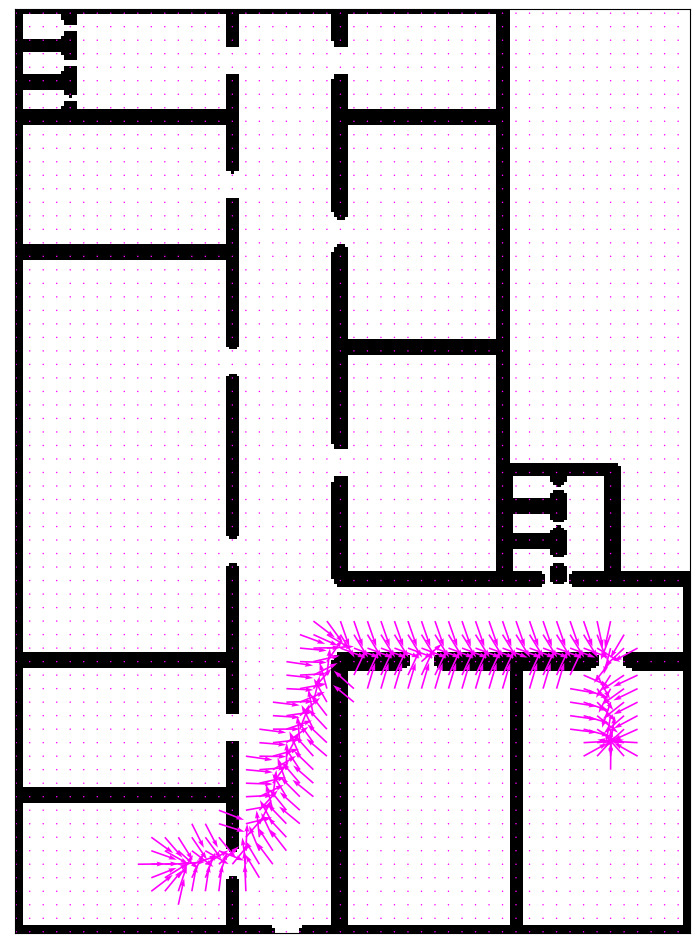

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def build_curve_tracking_field(matrix, origin, resolution, world_path,
                               corridor_width=1.5,
                               lateral_gain=2.0):

    path_xy = np.array([(p[0], p[2]) for p in world_path])

    width, _, depth = matrix.shape
    vx = np.zeros((width, depth))
    vy = np.zeros((width, depth))

    # Precompute segments
    segments = []
    for i in range(len(path_xy) - 1):
        p0 = path_xy[i]
        p1 = path_xy[i + 1]
        seg = p1 - p0
        length = np.linalg.norm(seg)
        if length > 1e-6:
            tangent = seg / length
            segments.append((p0, p1, tangent))

    for ix in range(width):
        for iz in range(depth):

            if matrix[ix, 0, iz] == 0:
                continue

            # Correct world coordinate of CELL CENTER
            x = origin[0] + (ix + 0.5) * resolution
            y = origin[1] + (iz + 0.5) * resolution
            point = np.array([x, y])

            best_dist = np.inf
            best_proj = None
            best_tangent = None

            for p0, p1, tangent in segments:
                seg_vec = p1 - p0
                seg_len_sq = np.dot(seg_vec, seg_vec)

                if seg_len_sq < 1e-8:
                    continue

                t = np.dot(point - p0, seg_vec) / seg_len_sq
                t = np.clip(t, 0.0, 1.0)
                proj = p0 + t * seg_vec

                dist = np.linalg.norm(point - proj)

                if dist < best_dist:
                    best_dist = dist
                    best_proj = proj
                    best_tangent = tangent

            if best_dist > corridor_width:
                continue

            lateral = point - best_proj
            velocity = best_tangent - lateral_gain * lateral

            norm = np.linalg.norm(velocity)
            if norm > 1e-6:
                velocity /= norm

            vx[ix, iz] = velocity[0]
            vy[ix, iz] = velocity[1]

    return vx, vy


def visualize_velocity_field(matrix, vx, vy, origin, resolution, step=5):

    width, _, depth = matrix.shape

    # Build world coordinate mesh (NO TRANSPOSE)
    x_coords = origin[0] + (np.arange(width) + 0.5) * resolution
    y_coords = origin[1] + (np.arange(depth) + 0.5) * resolution
    X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

    plt.figure(figsize=(10, 12))

    # For imshow, we transpose ONLY for display
    plt.imshow(
        matrix[:, 0, :].T,
        origin='lower',
        cmap='gray',
        interpolation='nearest',
        extent=[
            origin[0],
            origin[0] + width * resolution,
            origin[1],
            origin[1] + depth * resolution
        ]
    )

    # IMPORTANT: quiver must match mesh indexing
    plt.quiver(
        X[::step, ::step],
        Y[::step, ::step],
        vx[::step, ::step],
        vy[::step, ::step],
        color='magenta',
        scale=25
    )

    plt.xticks([])
    plt.yticks([])
    plt.show()


# ========================
# RUN
# ========================

vx, vy = build_curve_tracking_field(
    matrix,
    origin,
    res,
    world_path,
    corridor_width=1.5,
    lateral_gain=2.5
)

visualize_velocity_field(matrix, vx, vy, origin, res)

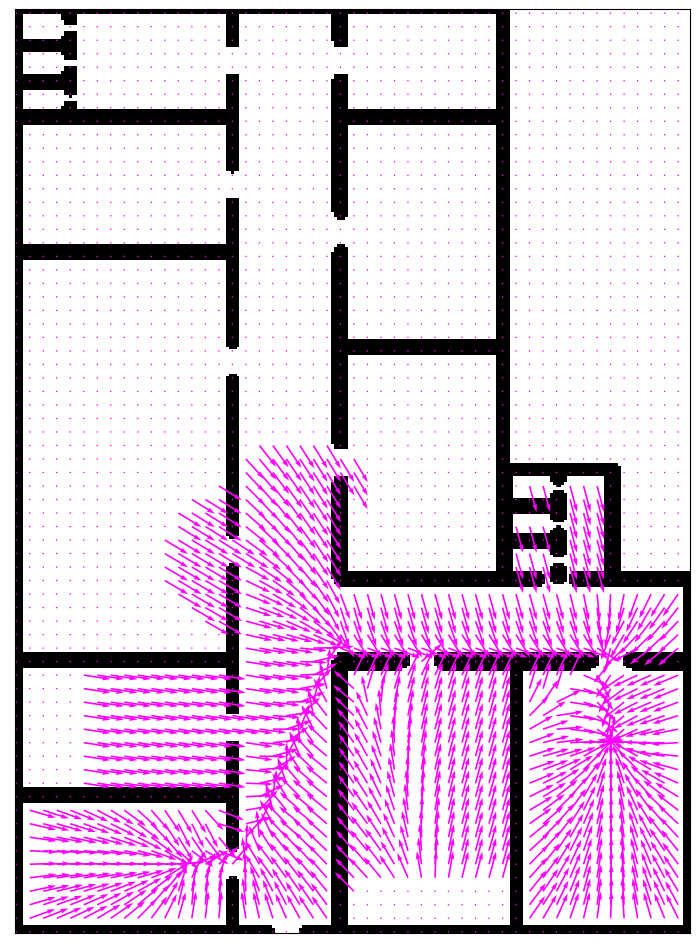

In [22]:
import numpy as np
import matplotlib.pyplot as plt
def diffuse_velocity_field(matrix, vx, vy, fixed_mask, iterations=300):
    """
    Diffuse velocity field over free space.

    matrix      : occupancy grid
    vx, vy      : initial velocity field (corridor values defined)
    fixed_mask  : True where velocity must remain fixed (corridor cells)
    """

    width, _, depth = matrix.shape

    vx = vx.copy()
    vy = vy.copy()

    free_mask = matrix[:, 0, :] == 1

    for _ in range(iterations):

        vx_new = vx.copy()
        vy_new = vy.copy()

        for ix in range(1, width - 1):
            for iz in range(1, depth - 1):

                if not free_mask[ix, iz]:
                    continue

                if fixed_mask[ix, iz]:
                    continue

                neighbors = [
                    (ix+1, iz),
                    (ix-1, iz),
                    (ix, iz+1),
                    (ix, iz-1),
                ]

                sum_vx = 0.0
                sum_vy = 0.0
                count = 0

                for nx, nz in neighbors:
                    if free_mask[nx, nz]:
                        sum_vx += vx[nx, nz]
                        sum_vy += vy[nx, nz]
                        count += 1

                if count > 0:
                    vx_new[ix, iz] = sum_vx / count
                    vy_new[ix, iz] = sum_vy / count

        vx = vx_new
        vy = vy_new

    # Normalize everywhere
    norm = np.sqrt(vx**2 + vy**2)
    mask = norm > 1e-6
    vx[mask] /= norm[mask]
    vy[mask] /= norm[mask]

    return vx, vy
def build_curve_tracking_field(matrix, origin, resolution, world_path,
                               corridor_width=1.5,
                               lateral_gain=2.0):

    width, _, depth = matrix.shape   # ✅ define first
    fixed_mask = np.zeros((width, depth), dtype=bool)

    path_xy = np.array([(p[0], p[2]) for p in world_path])

    vx = np.zeros((width, depth))
    vy = np.zeros((width, depth))

    # Precompute segments
    segments = []
    for i in range(len(path_xy) - 1):
        p0 = path_xy[i]
        p1 = path_xy[i + 1]
        seg = p1 - p0
        length = np.linalg.norm(seg)
        if length > 1e-6:
            tangent = seg / length
            segments.append((p0, p1, tangent))

    for ix in range(width):
        for iz in range(depth):

            if matrix[ix, 0, iz] == 0:
                continue

            x = origin[0] + (ix + 0.5) * resolution
            y = origin[1] + (iz + 0.5) * resolution
            point = np.array([x, y])

            best_dist = np.inf
            best_proj = None
            best_tangent = None

            for p0, p1, tangent in segments:
                seg_vec = p1 - p0
                seg_len_sq = np.dot(seg_vec, seg_vec)

                if seg_len_sq < 1e-8:
                    continue

                t = np.dot(point - p0, seg_vec) / seg_len_sq
                t = np.clip(t, 0.0, 1.0)
                proj = p0 + t * seg_vec

                dist = np.linalg.norm(point - proj)

                if dist < best_dist:
                    best_dist = dist
                    best_proj = proj
                    best_tangent = tangent

            if best_dist > corridor_width:
                continue

            lateral = point - best_proj
            velocity = best_tangent - lateral_gain * lateral

            norm = np.linalg.norm(velocity)
            if norm > 1e-6:
                velocity /= norm

            vx[ix, iz] = velocity[0]
            vy[ix, iz] = velocity[1]
            fixed_mask[ix, iz] = True   # ✅ correctly placed inside loop

    return vx, vy, fixed_mask


def visualize_velocity_field(matrix, vx, vy, origin, resolution, step=5):

    width, _, depth = matrix.shape

    # Build world coordinate mesh (NO TRANSPOSE)
    x_coords = origin[0] + (np.arange(width) + 0.5) * resolution
    y_coords = origin[1] + (np.arange(depth) + 0.5) * resolution
    X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

    plt.figure(figsize=(10, 12))

    # For imshow, we transpose ONLY for display
    plt.imshow(
        matrix[:, 0, :].T,
        origin='lower',
        cmap='gray',
        interpolation='nearest',
        extent=[
            origin[0],
            origin[0] + width * resolution,
            origin[1],
            origin[1] + depth * resolution
        ]
    )

    # IMPORTANT: quiver must match mesh indexing
    plt.quiver(
        X[::step, ::step],
        Y[::step, ::step],
        vx[::step, ::step],
        vy[::step, ::step],
        color='magenta',
        scale=25
    )

    plt.xticks([])
    plt.yticks([])
    plt.show()


# ========================
# RUN
# ========================

vx, vy, fixed_mask = build_curve_tracking_field(
    matrix,
    origin,
    res,
    world_path,
    corridor_width=1.5,
    lateral_gain=2.5
)

vx_full, vy_full = diffuse_velocity_field(
    matrix,
    vx,
    vy,
    fixed_mask,
    iterations=400
)

visualize_velocity_field(matrix, vx_full, vy_full, origin, res)

In [6]:
import json
import os
scenario_path = "/home/linh/ductai_nguyen_ws/Arena_ws/src/Arena/arena_simulation_setup/worlds/hospital_1/scenarios/grove_queuing"
with open(
    os.path.join(scenario_path, "scenario.json"),
    "r",
) as file:
    scenario = json.load(file)
dynamic = []
for dynamic_obs in scenario["dynamic"]:
    name = dynamic_obs["name"]
    dynamic_obs["behavior_tree"] = os.path.join(scenario_path, f"{name}.xml")
    dynamic.append(dynamic_obs)


In [7]:
dynamic

[{'id': 0,
  'name': 'hunav_1',
  'pos': [9.5, 2.5, 90.0],
  'model': 'female_adult_business_02',
  'waypoints': [],
  'behavior_tree': '/home/linh/ductai_nguyen_ws/Arena_ws/src/Arena/arena_simulation_setup/worlds/hospital_1/scenarios/grove_queuing/hunav_1.xml'},
 {'id': 1,
  'name': 'hunav_2',
  'pos': [9.5, 3.5, 90.0],
  'model': 'male_adult_construction_01',
  'waypoints': [],
  'behavior_tree': '/home/linh/ductai_nguyen_ws/Arena_ws/src/Arena/arena_simulation_setup/worlds/hospital_1/scenarios/grove_queuing/hunav_2.xml'},
 {'id': 2,
  'name': 'hunav_3',
  'pos': [9.5, 4.5, 90.0],
  'model': 'female_adult_medical_01',
  'waypoints': [],
  'behavior_tree': '/home/linh/ductai_nguyen_ws/Arena_ws/src/Arena/arena_simulation_setup/worlds/hospital_1/scenarios/grove_queuing/hunav_3.xml'},
 {'id': 3,
  'name': 'hunav_4',
  'pos': [9.5, 5.5, 90.0],
  'model': 'male_adult_police_04',
  'waypoints': [],
  'behavior_tree': '/home/linh/ductai_nguyen_ws/Arena_ws/src/Arena/arena_simulation_setup/worl